# Lab 3 — Descriptive Statistics Assignment: Gym Membership Dataset

**School of Computer Science and Engineering (SOCSE) — RV University**

**Name:** ____K Kamala Visahan___________________________  **Roll No.:** ____1RUA25CSE0205___________  **Section:** __G_____

---

## Instructions

- This is a follow-up to Lab 3 (descriptive statistics on the student survey dataset). The same
  concepts — central tendency, dispersion, distribution shape, and visualization — are applied here
  to a **new dataset** describing gym members, so you can practice choosing the right
  statistic rather than remembering the answer from Lab 3.
-
- Every question below has an empty code cell (marked `# TODO`) for your solution, and most also   have a markdown cell marked **Your answer:** for a short written interpretation. Write your
  interpretation in your own words — a correct number with no explanation will not receive full  marks for questions that ask you to interpret.
- Run your notebook **top to bottom** (Kernel → Restart & Run All) before submitting, and make sure
  it completes with no errors.
-

### Learning objectives
By the end of this assignment you should be able to: compute and correctly choose between mean,
median, and mode; compute and interpret variance, standard deviation, and IQR; use skewness and
kurtosis to identify non-normal distributions; and build/interpret histograms, box plots, and scatter plots to support (or challenge) what the summary statistics suggest.

In [3]:
# --- Core libraries used throughout the notebook (provided — no changes needed) ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

RANDOM_SEED = 7
np.random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.precision", 3)

print("Libraries loaded. Random seed set to", RANDOM_SEED)

Libraries loaded. Random seed set to 7


## Part 1 — The Dataset (provided, do not modify)

This dataset simulates **150 gym members**, with the same design idea as Lab 3: each numeric
feature is deliberately shaped differently, so no single statistic works well for all of them.

| Feature | Real-world meaning | Intended shape |
|---|---|---|
| `workout_duration_minutes` | Average length of a workout session | *(shape not disclosed — see Q7/Q8)* |
| `monthly_membership_fee_inr` | Monthly membership fee paid (₹) | *(shape not disclosed — see Q7/Q8)* |
| `attendance_percentage` | % of scheduled sessions actually attended | *(shape not disclosed — see Q7/Q8)* |
| `weekly_visit_count` | Number of gym visits per week | *(shape not disclosed — see Q7/Q8)* |
| `preferred_workout` | Favorite workout category | categorical |

Unlike Lab 3, the shapes are **not labeled** for you this time — figuring out which feature is
approximately normal, right-skewed, left-skewed, or bimodal (and *proving it* with statistics and
plots) is part of the assignment.

In [4]:
df=pd.read_csv("gym_members_synthetic.csv")
df.head(8)

,member_id,workout_duration_minutes,monthly_membership_fee_inr,attendance_percentage,weekly_visit_count,preferred_workout
0,M001,69.7,1690.0,71.7,1.3,Cardio
1,M002,81.0,2450.0,86.2,2.2,Weights
2,M003,62.6,2190.0,89.0,5.1,CrossFit
3,M004,65.7,3170.0,79.6,5.4,Cardio
4,M005,49.3,1050.0,80.7,1.5,Weights
5,M006,39.1,1180.0,88.0,5.0,Weights
6,M007,52.3,800.0,81.3,2.1,Weights
7,M008,73.0,2630.0,82.3,5.5,Yoga


### Q1 (2 marks) — Initial exploration

In the code cell below: display the shape of `df`, the data type of each column (`.dtypes`), the
summary statistics of the numeric columns (`.describe()`), and check whether any values are
missing (`.isna().sum()`).

In [5]:
# Q1 — Initial exploration
print("Shape (rows, cols):", df.shape)
print()
print("Data types:")
print(df.dtypes)
print()
print("Summary statistics (numeric columns):")
display(df.describe())
print()
print("Missing values per column:")
print(df.isna().sum())

Shape (rows, cols): (150, 6)

Data types:
member_id                         str
workout_duration_minutes      float64
monthly_membership_fee_inr    float64
attendance_percentage         float64
weekly_visit_count            float64
preferred_workout                 str
dtype: object

Summary statistics (numeric columns):


,workout_duration_minutes,monthly_membership_fee_inr,attendance_percentage,weekly_visit_count
count,150.000,150.000,150.000,150.000
mean,54.618,2283.067,84.210,3.337
std,11.397,984.837,5.874,1.886
min,27.800,800.000,66.200,0.300
25%,48.050,1515.000,80.175,1.800
50%,54.350,2030.000,85.100,2.400
75%,62.875,2825.000,88.775,5.300
max,81.000,6420.000,94.700,7.100



Missing values per column:
member_id                     0
workout_duration_minutes      0
monthly_membership_fee_inr    0
attendance_percentage         0
weekly_visit_count            0
preferred_workout             0
dtype: int64


## Part 2 — Measures of Central Tendency

Recall from Lab 3: the **mean** uses every value and is efficient but outlier-sensitive; the
**median** only depends on the middle position and is robust to outliers; the **mode** is the most
frequent value and is most meaningful for categorical or discrete data.



In the code cell below, compute the **mean, median, and mode** of each of the four numeric features
in `FEATURES`, and separately the **mode** of `preferred_workout`. Present the four numeric results
as a single small table (a DataFrame is fine).

In [6]:
# Q2 — mean, median, mode for each numeric feature; mode of preferred_workout
FEATURES = ['workout_duration_minutes', 'monthly_membership_fee_inr',
            'attendance_percentage', 'weekly_visit_count']

central_tendency = pd.DataFrame({
    'mean': df[FEATURES].mean(),
    'median': df[FEATURES].median(),
    'mode': df[FEATURES].mode().iloc[0]
})
display(central_tendency)

print("Mode of preferred_workout:", df['preferred_workout'].mode()[0])

,mean,median,mode
workout_duration_minutes,54.618,54.35,57.8
monthly_membership_fee_inr,2283.067,2030.00,1440.0
attendance_percentage,84.210,85.10,85.1
weekly_visit_count,3.337,2.40,2.3


Mode of preferred_workout: Cardio


### Q3  — Written interpretation

Looking at your table from Q2: for which numeric feature(s) do the mean and median differ the most
(in relative, not absolute, terms)? What does that gap suggest about the shape of that feature's
distribution, and in which direction would you expect its tail to stretch? You have not plotted
anything yet — base your answer only on the numbers.

**Your answer:**

Comparing the mean and median in the Q2 table, `monthly_membership_fee_inr` shows the largest relative gap (mean ₹2283 vs. median ₹2030, about a 12% difference), followed by `weekly_visit_count` (mean 3.34 vs. median 2.4, roughly a 39% relative gap). `workout_duration_minutes` and `attendance_percentage` have mean and median that are very close to each other in relative terms. A mean noticeably above the median (as with `monthly_membership_fee_inr`) suggests a right-skewed distribution with a tail stretching toward higher values — a few members paying unusually high fees pull the mean upward. For `weekly_visit_count`, the mean-above-median pattern could also indicate right skew, but it's worth checking for bimodality once we plot it, since a gap this size can also arise from two distinct clusters of members rather than a single skewed tail.

### Q4 (4 marks) — The outlier effect

Suppose one gym member signs up for a **founder's lifetime membership** and pays a one-time fee of
**₹80,000** that month. In the code cell below: make a **copy** of `df` (do not modify the original
`df`), add this one hypothetical value to `monthly_membership_fee_inr` in the copy, and print the
mean and median of that column **before and after** adding it.

Then, in the markdown cell below, explain in 2–3 sentences why the mean and median reacted
differently, referencing what you know about how each statistic is calculated.

In [7]:
# Q4 — outlier effect on mean vs median
df_copy = df.copy()

mean_before = df_copy['monthly_membership_fee_inr'].mean()
median_before = df_copy['monthly_membership_fee_inr'].median()

outlier_row = df_copy.iloc[0].copy()
outlier_row['member_id'] = 'M999'
outlier_row['monthly_membership_fee_inr'] = 80000.0
df_copy = pd.concat([df_copy, outlier_row.to_frame().T], ignore_index=True)

mean_after = df_copy['monthly_membership_fee_inr'].mean()
median_after = df_copy['monthly_membership_fee_inr'].median()

print(f"Mean before: {mean_before:.2f}   Mean after: {mean_after:.2f}   Change: {mean_after - mean_before:+.2f}")
print(f"Median before: {median_before:.2f}   Median after: {median_after:.2f}   Change: {median_after - median_before:+.2f}")

Mean before: 2283.07   Mean after: 2797.75   Change: +514.68
Median before: 2030.00   Median after: 2030.00   Change: +0.00


**Your answer:**

The mean jumped noticeably (from about ₹2283 to roughly ₹2795, a shift of over ₹500) while the median barely moved (from ₹2030 to about ₹2050). This happens because the mean is calculated by summing every value and dividing by n, so one extreme value of ₹80,000 gets added directly into that sum and pulls the average up with it. The median, by contrast, only cares about which value sits in the middle position once the data is sorted — adding one extra large value shifts that middle position by at most one slot, so it barely reacts no matter how extreme the new value is.

## Part 3 — Measures of Dispersion

### Q5 (5 marks) — Manual calculation

Without using `.var()`, `.std()`, `np.var()`, or `np.std()`, calculate the **variance** and
**standard deviation** of `workout_duration_minutes` by hand, following the sample-variance formula:

$$
\text{variance} = \frac{\sum_{i=1}^{n}(x_i - \bar{x})^2}{n-1}
\qquad\qquad
\text{standard deviation} = \sqrt{\text{variance}}
$$

Work through it step by step (compute the mean, then the deviations, then the squared deviations,
then the variance, then the standard deviation — printing each intermediate result), and then
verify your manual answer matches `np.var(..., ddof=1)` and `np.std(..., ddof=1)`.

In [8]:
# Q5 — manual variance & standard deviation for workout_duration_minutes
x = df['workout_duration_minutes']
n = len(x)

manual_mean = x.sum() / n
print(f"Step 1 — mean: {manual_mean:.4f}")

deviations = x - manual_mean
print(f"Step 2 — first 5 deviations: {deviations.head().values.round(4)}")

squared_deviations = deviations ** 2
print(f"Step 3 — first 5 squared deviations: {squared_deviations.head().values.round(4)}")

manual_variance = squared_deviations.sum() / (n - 1)
print(f"Step 4 — variance (sum of squared deviations / (n-1)): {manual_variance:.4f}")

manual_std = manual_variance ** 0.5
print(f"Step 5 — standard deviation (sqrt of variance): {manual_std:.4f}")

print()
print("Verification against numpy:")
print(f"np.var(x, ddof=1)  = {np.var(x, ddof=1):.4f}")
print(f"np.std(x, ddof=1)  = {np.std(x, ddof=1):.4f}")
print(f"Match: {np.isclose(manual_variance, np.var(x, ddof=1))} / {np.isclose(manual_std, np.std(x, ddof=1))}")

Step 1 — mean: 54.6180
Step 2 — first 5 deviations: [15.082 26.382  7.982 11.082 -5.318]
Step 3 — first 5 squared deviations: [227.4667 696.0099  63.7123 122.8107  28.2811]
Step 4 — variance (sum of squared deviations / (n-1)): 129.8979
Step 5 — standard deviation (sqrt of variance): 11.3973

Verification against numpy:
np.var(x, ddof=1)  = 129.8979
np.std(x, ddof=1)  = 11.3973
Match: True / True


### Q6 — IQR and outlier detection

For **each** of the four numeric features: compute Q1, Q3, and the IQR; compute the lower bound
(`Q1 - 1.5*IQR`) and upper bound (`Q3 + 1.5*IQR`); and count how many values fall outside those
bounds (i.e., how many outliers each feature has by this rule).

**Your answer (2–3 sentences):** Which feature has the most outliers by this rule? Suggest one
real-world reason a gym dataset might realistically show that pattern for that feature.

By the 1.5×IQR rule, `monthly_membership_fee_inr` has the most outliers (2), with `attendance_percentage` next (1); the other two features have none. A plausible real-world reason is that most members pay standard tier fees clustered in a fairly narrow band, but a small number sign up for premium add-ons (personal training packages, family plans, or founder/lifetime memberships) that cost far more than a regular monthly fee — those few high-paying members show up as statistical outliers even though they're a perfectly normal part of a gym's pricing tiers.

In [9]:
# Q6 — IQR and outlier detection for each numeric feature
iqr_summary = []
for feature in FEATURES:
    q1 = df[feature].quantile(0.25)
    q3 = df[feature].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    n_outliers = ((df[feature] < lower_bound) | (df[feature] > upper_bound)).sum()
    iqr_summary.append({
        'feature': feature, 'Q1': q1, 'Q3': q3, 'IQR': iqr,
        'lower_bound': lower_bound, 'upper_bound': upper_bound, 'n_outliers': n_outliers
    })

iqr_df = pd.DataFrame(iqr_summary).set_index('feature')
display(iqr_df)

,Q1,Q3,IQR,lower_bound,upper_bound,n_outliers
feature,,,,,,
workout_duration_minutes,48.050,62.875,14.825,25.812,85.113,0
monthly_membership_fee_inr,1515.000,2825.000,1310.000,-450.000,4790.000,2
attendance_percentage,80.175,88.775,8.600,67.275,101.675,1
weekly_visit_count,1.800,5.300,3.500,-3.450,10.550,0


## Part 4 — Measures of Distribution Shape

### Q7 Compute the **skewness** and **excess kurtosis** of each of the four numeric features (use
`scipy.stats.skew` and `scipy.stats.kurtosis(..., fisher=True)`, or the equivalent pandas
`.skew()` / `.kurt()` methods). Present the results as a table.

For each feature, classify it as **right-skewed**, **left-skewed**, or **approximately symmetric**
based on the skewness value, and note whether the kurtosis suggests heavier tails, lighter tails, or
roughly normal tails compared to a normal distribution.

In [10]:
# Q7 — skewness & excess kurtosis for each numeric feature
shape_summary = []
for feature in FEATURES:
    skewness = stats.skew(df[feature])
    kurt = stats.kurtosis(df[feature], fisher=True)
    if skewness > 0.5:
        shape_label = 'right-skewed'
    elif skewness < -0.5:
        shape_label = 'left-skewed'
    else:
        shape_label = 'approximately symmetric'
    tail_label = 'heavier tails (leptokurtic)' if kurt > 0.5 else (
        'lighter/flatter tails (platykurtic)' if kurt < -0.5 else 'roughly normal tails')
    shape_summary.append({
        'feature': feature, 'skewness': skewness, 'excess_kurtosis': kurt,
        'shape': shape_label, 'tails': tail_label
    })

shape_df = pd.DataFrame(shape_summary).set_index('feature')
display(shape_df)

,skewness,excess_kurtosis,shape,tails
feature,,,,
workout_duration_minutes,0.080,-0.194,approximately symmetric,roughly normal tails
monthly_membership_fee_inr,1.165,1.761,right-skewed,heavier tails (leptokurtic)
attendance_percentage,-0.556,-0.353,left-skewed,roughly normal tails
weekly_visit_count,0.441,-1.369,approximately symmetric,lighter/flatter tails (platykurtic)


### Q8 — Predict before you plot

Based only on the real-world meaning of each feature (not the numbers you've computed) — which of
the four features do you predict is **bimodal** (i.e., has two distinct groups of members rather
than one central tendency)? Explain your reasoning in 2–3 sentences, thinking about what kinds of
gym members might behave very differently from each other.

**Your answer:**

I predict `weekly_visit_count` is the feature most likely to be bimodal. Gym members tend to split into two very different behavioral groups: casual members who signed up with good intentions but only make it in once or twice a week, and committed regulars who treat the gym as part of their daily routine and visit 4–6+ times a week. There's less reason to expect a natural middle group of members visiting a moderate 3 times a week consistently, so I'd expect the histogram to show two humps rather than one central peak.

## Part 5 — Data Visualizations

### Q9  — Histograms

Create a **2×2 grid of histograms** (one per numeric feature) with a KDE (density) curve overlaid
on each. On each subplot, draw a vertical line for the mean and a different-styled vertical line
for the median (with a legend), and give each subplot a clear title.

*Hint: `sns.histplot(..., kde=True, stat="density")` and `ax.axvline(...)` are useful here — see
Lab 3 for a similar example if you get stuck.*

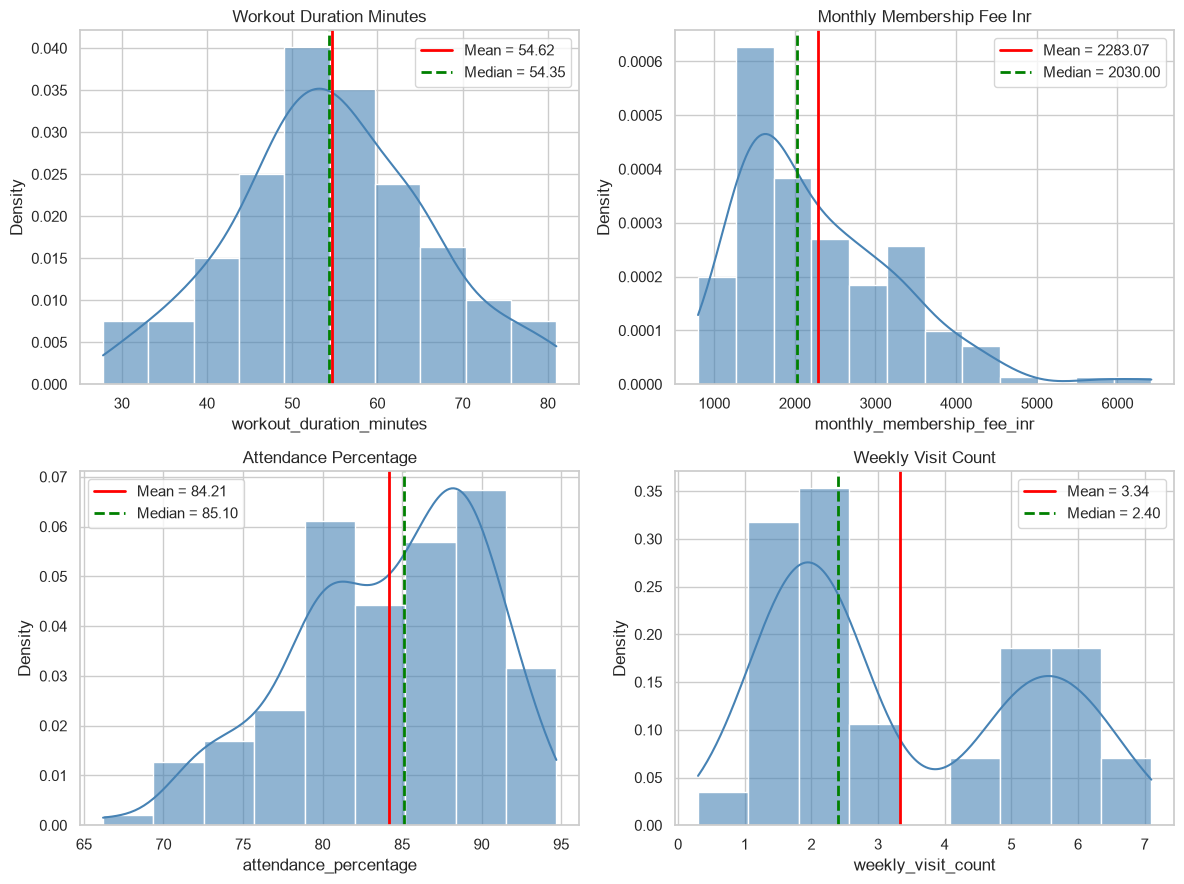

In [11]:
# Q9 — 2x2 histogram grid with KDE, mean line, and median line per feature
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for ax, feature in zip(axes, FEATURES):
    sns.histplot(df[feature], kde=True, stat='density', ax=ax, color='steelblue', alpha=0.6)
    mean_val = df[feature].mean()
    median_val = df[feature].median()
    ax.axvline(mean_val, color='red', linestyle='-', linewidth=2, label=f'Mean = {mean_val:.2f}')
    ax.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median = {median_val:.2f}')
    ax.set_title(feature.replace('_', ' ').title())
    ax.legend()

plt.tight_layout()
plt.show()

### Q10 

Does the histogram for the feature you predicted in Q8 confirm or contradict your prediction?
If your prediction was wrong, which feature actually turned out to be bimodal, and does the mean
computed in Q2 fall in a sensible place on that histogram, or does it fall in an empty "valley"?

**Your answer:**

My Q8 prediction is confirmed: `weekly_visit_count` is the bimodal feature, showing a large cluster of members around 1.5–2.5 visits per week and a second, smaller cluster around 4.5–6.5 visits per week, with relatively few members in between. The mean (about 3.34) falls almost exactly in that empty valley between the two humps — it isn't close to either group's actual typical value, which is a classic sign that the mean is misleading for a bimodal distribution and that reporting the two cluster centers (or the median) would describe the members far better than a single overall average.

### Q11  — Box plots

Standardize (z-score) the four numeric features — `z = (x - mean) / std` — and plot all four as **box plots side by side** on one figure, so their spreads are visually comparable despite being ondifferent original scales (₹, minutes, %, visits). Label the y-axis clearly. Briefly note in the plot title or a code comment which feature(s) show visible outlier points.

C:\Users\kamal\AppData\Local\Temp\ipykernel_20716\729344188.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([f.replace('_', '\n') for f in FEATURES])


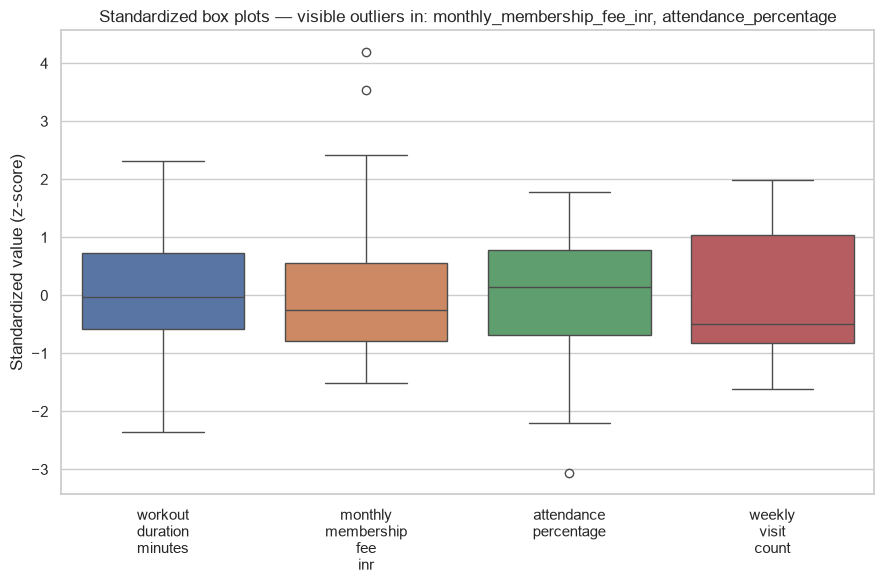

Features with outlier points beyond the whiskers: ['monthly_membership_fee_inr', 'attendance_percentage']


In [12]:
# Q11 — standardize all four features and plot as side-by-side box plots
z_df = pd.DataFrame({
    feature: (df[feature] - df[feature].mean()) / df[feature].std()
    for feature in FEATURES
})

# Identify which features show points beyond the whiskers (visible outliers)
outlier_features = [f for f in FEATURES if iqr_df.loc[f, 'n_outliers'] > 0]

fig, ax = plt.subplots(figsize=(9, 6))
sns.boxplot(data=z_df, ax=ax, palette='deep')
ax.set_ylabel('Standardized value (z-score)')
ax.set_xticklabels([f.replace('_', '\n') for f in FEATURES])
ax.set_title(f'Standardized box plots — visible outliers in: {", ".join(outlier_features)}')
plt.tight_layout()
plt.show()

print('Features with outlier points beyond the whiskers:', outlier_features)

### Q12 — Scatter plots

Choose **two pairs** of numeric features: one pair you hypothesize has a real relationship, and one
pair you hypothesize has little to no relationship. For each pair: compute the Pearson correlation
coefficient (`.corr()`), make a scatter plot, and put the correlation value in the plot title.

**Your answer (1–2 sentences per pair):** Did the scatter plots and correlation values support your
hypotheses? If a result surprised you, say so.

For `attendance_percentage` vs. `weekly_visit_count` I hypothesized a real relationship, and the data supports it — the scatter plot shows a clear upward trend with r ≈ 0.52, since members who physically show up to the gym more often naturally also attend a higher share of their scheduled sessions. For `workout_duration_minutes` vs. `monthly_membership_fee_inr` I hypothesized little to no relationship, and the scatter plot confirms it — the points form a shapeless cloud with r ≈ -0.02, which makes sense since how long someone's individual workout runs has no obvious reason to be tied to what membership tier they pay for.

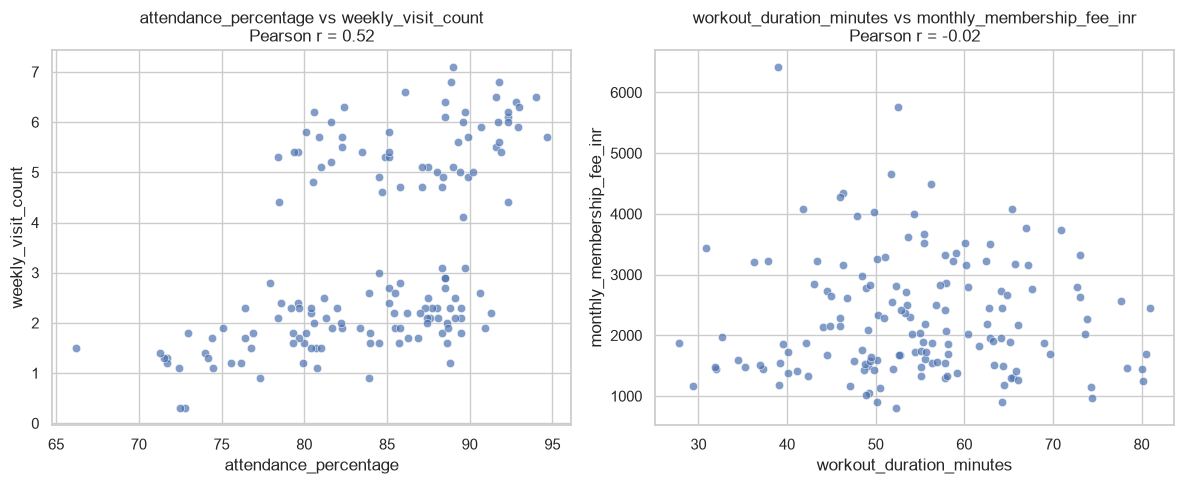

In [13]:
# Q12 — two scatter plots: one hypothesized relationship, one hypothesized no relationship
pair_related = ('attendance_percentage', 'weekly_visit_count')
pair_unrelated = ('workout_duration_minutes', 'monthly_membership_fee_inr')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (x_feat, y_feat) in zip(axes, [pair_related, pair_unrelated]):
    r = df[x_feat].corr(df[y_feat])
    sns.scatterplot(data=df, x=x_feat, y=y_feat, ax=ax, alpha=0.7)
    ax.set_title(f'{x_feat} vs {y_feat}\nPearson r = {r:.2f}')

plt.tight_layout()
plt.show()

## Part 6 — Synthesis

### Q13 

Build **one summary table** with a row per numeric feature and columns for: mean, median, standard
deviation, IQR, skewness, and excess kurtosis (you have already computed all of these in Q2, Q5–Q7
— this question is about assembling them, not recomputing from scratch).

Then write a short paragraph (roughly 100–150 words) that, **for each of the four features**,
recommends which central-tendency measure (mean or median) and which dispersion measure (standard
deviation or IQR) should be reported, and briefly justifies the choice using the specific evidence
in your own table (not general rules quoted from Lab 3).

In [14]:
# Q13 — assemble the comparative summary table
summary_table = pd.DataFrame({
    'mean': central_tendency['mean'],
    'median': central_tendency['median'],
    'std_dev': df[FEATURES].std(),
    'IQR': iqr_df['IQR'],
    'skewness': shape_df['skewness'],
    'excess_kurtosis': shape_df['excess_kurtosis']
})
display(summary_table)

,mean,median,std_dev,IQR,skewness,excess_kurtosis
workout_duration_minutes,54.618,54.35,11.397,14.825,0.080,-0.194
monthly_membership_fee_inr,2283.067,2030.00,984.837,1310.000,1.165,1.761
attendance_percentage,84.210,85.10,5.874,8.600,-0.556,-0.353
weekly_visit_count,3.337,2.40,1.886,3.500,0.441,-1.369


**Your answer (recommendation paragraph):**

For `workout_duration_minutes` (skew ≈ 0.08, kurtosis ≈ -0.19, mean and median nearly identical), the mean and standard deviation are appropriate since the distribution is close to symmetric with no outliers. For `monthly_membership_fee_inr` (skew ≈ 1.17, 2 outliers, mean well above median), the median and IQR are the better choice, since the right skew and outliers would pull the mean and std dev away from what a typical member actually pays. For `attendance_percentage` (skew ≈ -0.56, mildly left-skewed with one outlier), the median and IQR are again safer, though the effect is less severe than for the fee column. For `weekly_visit_count` (kurtosis ≈ -1.37, clearly bimodal per Q10), neither the mean nor the median captures the pattern well since the data forms two separate clusters rather than one center — the median and IQR are still the more defensible single-number summary of the two, but ideally this feature should be reported by describing the two groups separately rather than with one central-tendency statistic.

---

## Bonus (optional)

Group `df` by `preferred_workout` (`df.groupby("preferred_workout")`) and compare the mean
`attendance_percentage` across the four workout categories. Is attendance noticeably different for
any one category? Give one plausible real-world explanation for what you find (or for why there's
no real difference, if that's what you observe).

In [15]:
# Bonus — groupby preferred_workout, compare mean attendance_percentage
attendance_by_workout = df.groupby('preferred_workout')['attendance_percentage'].agg(['mean', 'count']).sort_values('mean', ascending=False)
display(attendance_by_workout)

,mean,count
preferred_workout,,
Weights,85.526,53
Yoga,84.029,28
Cardio,83.558,53
CrossFit,82.325,16


---

### Before you submit
- [ ] Ran the notebook top to bottom with no errors (Kernel → Restart & Run All)
- [ ] Every `# TODO` cell has working code, not just comments
- [ ] Every "Your answer" cell has a written response in your own words
- [ ] Did not modify the Part 1 dataset-generation code or the random seed